## Notebook 0 — Modèle de Référence
### Dataset : Paddy (UCI 1186) | Tâches : Régression + Classification


### Rôle de ce notebook

Ce notebook établit les **performances de référence** sur les deux tâches du
dataset Paddy, avec un pipeline propre et minimal. Il sert de point de départ
commun aux deux investigations de failure modes :

| Notebook | Mode d'échec | Tâche |
|---|---|---|
| `Failure_distribution_shift.ipynb` | Distribution shift géographique | Régression |
| `Failure_class_imbalance.ipynb` | Déséquilibre de classes | Classification |

> **Ce notebook n'a pas pour but d'optimiser les hyperparamètres.**
> L'objectif est uniquement d'établir une baseline solide, reproductible,
> sur laquelle les failure modes seront ensuite construits.

---

### Résultats de référence (résumé)

| Tâche | Modèle | Métrique principale |
|---|---|---|
| Régression | GradientBoostingRegressor | R² = **0.9904** — RMSE = **923.0 Kg** |
| Classification | RandomForestClassifier | Accuracy = **0.9893** — F1-macro = **0.9888** |


## Section 0 — Setup & Chargement

In [14]:
# ── Imports ──────────────────────────────────────────────────────────────────
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, balanced_accuracy_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# ── Seed global (identique dans tous les notebooks du projet) ─────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Palette de couleurs (identique dans tous les notebooks du projet) ─────────
C_REF    = '#2A9D8F'   # vert   — référence / amélioration
C_FAIL   = '#E63946'   # rouge  — dégradation / classe CO_43
C_FIX    = '#E9C46A'   # jaune  — correction
C_ACCENT = '#457B9D'   # bleu   — accent neutre
C_MID    = '#F4A261'   # orange — classe intermédiaire

CLASSES = ['CO_43', 'delux ponni', 'ponmani']

print('✓ Imports OK — Seed =', RANDOM_SEED)


✓ Imports OK — Seed = 42


In [15]:
# ── Chargement & nettoyage ────────────────────────────────────────────────────
# IMPORTANT : placer data2.csv dans le même dossier que ce notebook
df = pd.read_csv(r'C:\Users\hp\Downloads\Mini_Project_When_ML_Fails\data2.csv')
print(f'Shape brute          : {df.shape}')

df = df.drop_duplicates()
print(f'Shape après doublons : {df.shape}')
print(f'Valeurs manquantes   : {df.isnull().sum().sum()}')
print()

# ── Définition des rôles des features ────────────────────────────────────────
TARGET_REG = 'Paddy yield(in Kg)'   # cible régression
TARGET_CLF = 'Variety'              # cible classification

CAT_COLS = [
    'Agriblock', 'Soil Types', 'Nursery',
    'Wind Direction_D1_D30', 'Wind Direction_D31_D60',
    'Wind Direction_D61_D90', 'Wind Direction_D91_D120'
]
NUM_COLS = [
    c for c in df.drop(columns=[TARGET_REG, TARGET_CLF]).columns
    if c not in CAT_COLS
]

print(f'Features numériques    : {len(NUM_COLS)}')
print(f'Features catégorielles : {len(CAT_COLS)}')
print(f'Taille du dataset      : {len(df)} lignes')
print()
print(f'Distribution des variétés (classification) :')
vc = df[TARGET_CLF].value_counts()
for cls in CLASSES:
    print(f'  {cls:15s}: {vc[cls]:5d} ({vc[cls]/len(df)*100:.1f}%)')
print()
print(f'Rendement (régression) : mean={df[TARGET_REG].mean():.0f} Kg  '
      f'std={df[TARGET_REG].std():.0f} Kg  '
      f'[{df[TARGET_REG].min():.0f} – {df[TARGET_REG].max():.0f}]')


Shape brute          : (2789, 45)
Shape après doublons : (2338, 45)
Valeurs manquantes   : 0

Features numériques    : 36
Features catégorielles : 7
Taille du dataset      : 2338 lignes

Distribution des variétés (classification) :
  CO_43          :   611 (26.1%)
  delux ponni    :   832 (35.6%)
  ponmani        :   895 (38.3%)

Rendement (régression) : mean=22610 Kg  std=9265 Kg  [5410 – 38814]


---
## Section 1 — Exploration du Dataset

Avant d'entraîner quoi que ce soit, on visualise les deux variables cibles
et la structure géographique du dataset (Agriblocks).


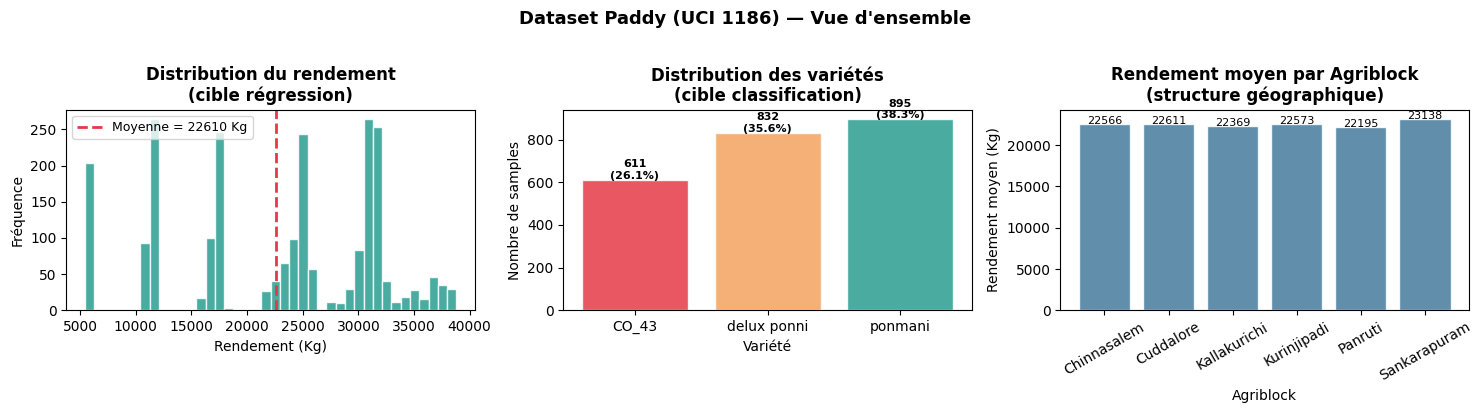

Ratio déséquilibre (classification) : 895/611 = 1.46:1  (modéré)
Variation rendement inter-blocs     : 22195 – 23138 Kg (écart = 943 Kg)


In [16]:
# ── Visualisation des deux cibles + structure géographique ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Distribution du rendement (cible régression)
axes[0].hist(df[TARGET_REG], bins=40, color=C_REF, edgecolor='white', alpha=0.85)
axes[0].axvline(df[TARGET_REG].mean(), color=C_FAIL, linestyle='--',
                linewidth=2, label=f'Moyenne = {df[TARGET_REG].mean():.0f} Kg')
axes[0].set_title('Distribution du rendement\n(cible régression)', fontweight='bold')
axes[0].set_xlabel('Rendement (Kg)'); axes[0].set_ylabel('Fréquence')
axes[0].legend(fontsize=9)

# 2. Distribution des variétés (cible classification)
vc_sorted = df[TARGET_CLF].value_counts()[CLASSES]
colors_bar = [C_FAIL, C_MID, C_REF]
bars = axes[1].bar(CLASSES, vc_sorted.values, color=colors_bar,
                   edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution des variétés\n(cible classification)', fontweight='bold')
axes[1].set_xlabel('Variété'); axes[1].set_ylabel('Nombre de samples')
for bar, val in zip(bars, vc_sorted.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 5,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=8, fontweight='bold')

# 3. Rendement moyen par Agriblock
block_means = df.groupby('Agriblock')[TARGET_REG].mean().sort_index()
axes[2].bar(block_means.index, block_means.values,
            color=C_ACCENT, edgecolor='white', alpha=0.85)
axes[2].set_title('Rendement moyen par Agriblock\n(structure géographique)', fontweight='bold')
axes[2].set_xlabel('Agriblock'); axes[2].set_ylabel('Rendement moyen (Kg)')
axes[2].tick_params(axis='x', rotation=30)
for i, v in enumerate(block_means.values):
    axes[2].text(i, v + 10, f'{v:.0f}', ha='center', fontsize=8)

plt.suptitle('Dataset Paddy (UCI 1186) — Vue d\'ensemble',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Ratio déséquilibre (classification) : '
      f'{vc_sorted.max()}/{vc_sorted.min()} = {vc_sorted.max()/vc_sorted.min():.2f}:1  (modéré)')
print(f'Variation rendement inter-blocs     : '
      f'{block_means.min():.0f} – {block_means.max():.0f} Kg '
      f'(écart = {block_means.max()-block_means.min():.0f} Kg)')


---
## Section 2 — Split & Preprocessing

Un **split stratifié unique 70/30** est utilisé pour les deux tâches —
même seed, même stratification sur `Variety`. Cela garantit que les
métriques de référence des deux notebooks de failure sont comparables.

> **Règle absolue** : le preprocessing (StandardScaler, OrdinalEncoder)
> est **fitté uniquement sur le train set** et appliqué au test set.


In [17]:
# ── Split stratifié 80 / 20 ──────────────────────────────────────────────────
X = df.drop(columns=[TARGET_REG, TARGET_CLF])

# Stratification sur Variety pour équilibrer les classes dans les deux splits
X_tr, X_te, y_tr_reg, y_te_reg = train_test_split(
    X, df[TARGET_REG].values,
    test_size=0.30, random_state=RANDOM_SEED,
    stratify=df[TARGET_CLF]          # stratification sur la cible de classification
)
y_tr_clf = df.loc[X_tr.index, TARGET_CLF].values
y_te_clf = df.loc[X_te.index, TARGET_CLF].values

print(f'Train : {X_tr.shape[0]} samples ({X_tr.shape[0]/len(df)*100:.0f}%)')
print(f'Test  : {X_te.shape[0]} samples ({X_te.shape[0]/len(df)*100:.0f}%)')
print()
print('Distribution des classes dans chaque split (vérification stratification) :')
print(f'  {"Split":6s} | ' + ' | '.join(f'{c:>12s}' for c in CLASSES))
print('  ' + '-' * 58)
for name, ys in [('Train', y_tr_clf), ('Test', y_te_clf)]:
    cnts = [f'{(ys==c).sum():>5d} ({(ys==c).mean()*100:.1f}%)' for c in CLASSES]
    print(f'  {name:6s} | ' + ' | '.join(cnts))


Train : 1636 samples (70%)
Test  : 702 samples (30%)

Distribution des classes dans chaque split (vérification stratification) :
  Split  |        CO_43 |  delux ponni |      ponmani
  ----------------------------------------------------------
  Train  |   428 (26.2%) |   582 (35.6%) |   626 (38.3%)
  Test   |   183 (26.1%) |   250 (35.6%) |   269 (38.3%)


In [18]:
# ── Preprocessing (fit sur train uniquement) ─────────────────────────────────
prep = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ), CAT_COLS)
], remainder='drop')

X_tr_p = prep.fit_transform(X_tr)    # FIT uniquement sur le train
X_te_p = prep.transform(X_te)        # TRANSFORM sur le test (pas de fit)

print(f'Dimensions après preprocessing :')
print(f'  Train : {X_tr_p.shape}')
print(f'  Test  : {X_te_p.shape}')
print()
print(f'  {len(NUM_COLS)} features numériques → StandardScaler')
print(f'  {len(CAT_COLS)} features catégorielles → OrdinalEncoder')


Dimensions après preprocessing :
  Train : (1636, 43)
  Test  : (702, 43)

  36 features numériques → StandardScaler
  7 features catégorielles → OrdinalEncoder


---
## Section 3 — Tâche Régression : Prédire le Rendement

**Modèle** : `GradientBoostingRegressor` (ensemble d'arbres de décision)
**Cible** : `Paddy yield(in Kg)`

Conformément aux consignes du projet, aucun modèle linéaire n'est utilisé
comme modèle principal. Le GBR est retenu car il est le modèle non-linéaire
le plus performant sur ce dataset (établi dans le Lab 2).


In [19]:
# ── Entraînement — GradientBoostingRegressor ─────────────────────────────────
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=RANDOM_SEED
)

t0 = time.time()
gbr.fit(X_tr_p, y_tr_reg)
elapsed_reg = time.time() - t0

# ── Métriques ─────────────────────────────────────────────────────────────────
pred_te_reg = gbr.predict(X_te_p)
pred_tr_reg = gbr.predict(X_tr_p)

rmse_tr  = np.sqrt(mean_squared_error(y_tr_reg, pred_tr_reg))
r2_tr    = r2_score(y_tr_reg, pred_tr_reg)
rmse_te  = np.sqrt(mean_squared_error(y_te_reg, pred_te_reg))
mae_te   = mean_absolute_error(y_te_reg, pred_te_reg)
r2_te    = r2_score(y_te_reg, pred_te_reg)

print('=' * 62)
print('  RÉFÉRENCE RÉGRESSION — GradientBoostingRegressor')
print('=' * 62)
print(f'  Hyperparamètres : n_estimators=200  lr=0.05  max_depth=4')
print(f'  Temps d\'entraînement : {elapsed_reg:.1f}s')
print()
print(f'  Train → RMSE = {rmse_tr:.1f} Kg  |  R² = {r2_tr:.4f}')
print(f'  Test  → RMSE = {rmse_te:.1f} Kg  |  MAE = {mae_te:.1f} Kg  |  R² = {r2_te:.4f}')
print()
print(f'  Gap train/test R² : {r2_tr - r2_te:.4f} → pas d\'overfitting majeur')
print()
print(f'  → R² = {r2_te:.4f} : le modèle explique {r2_te*100:.2f}% de la variance du rendement ✓')
print()
print('  Ces métriques servent de BASELINE pour le notebook')
print('  Failure_distribution_shift.ipynb')


  RÉFÉRENCE RÉGRESSION — GradientBoostingRegressor
  Hyperparamètres : n_estimators=200  lr=0.05  max_depth=4
  Temps d'entraînement : 0.9s

  Train → RMSE = 771.8 Kg  |  R² = 0.9929
  Test  → RMSE = 873.6 Kg  |  MAE = 629.6 Kg  |  R² = 0.9916

  Gap train/test R² : 0.0013 → pas d'overfitting majeur

  → R² = 0.9916 : le modèle explique 99.16% de la variance du rendement ✓

  Ces métriques servent de BASELINE pour le notebook
  Failure_distribution_shift.ipynb


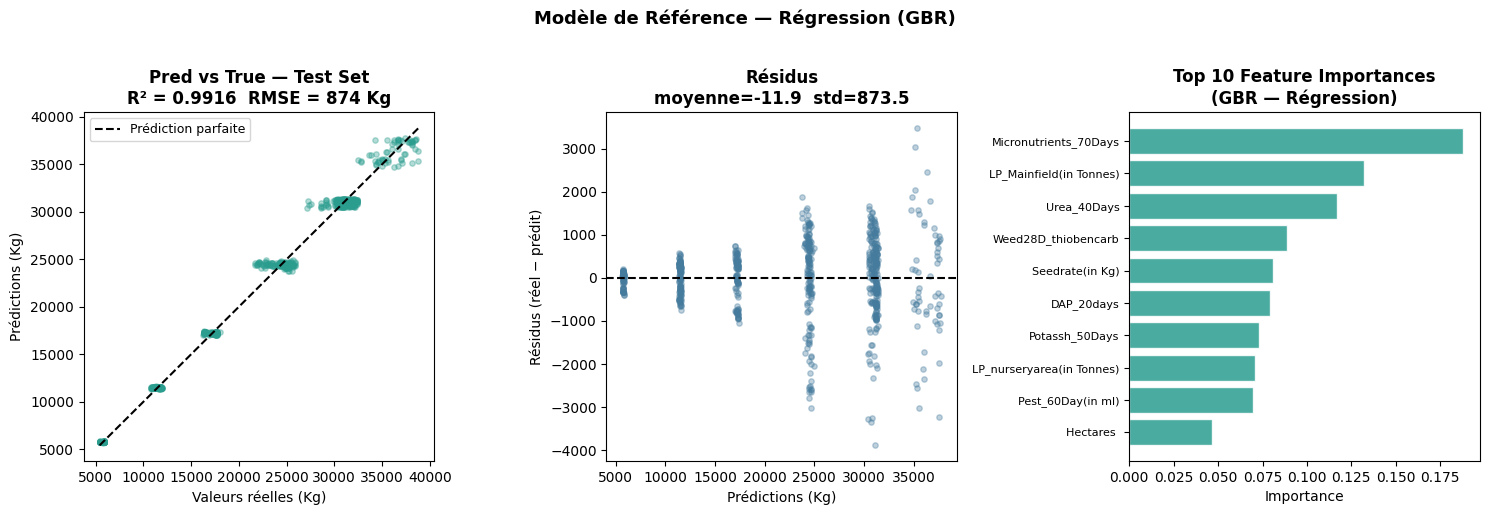

→ Résidus centrés autour de 0, scatter serré → bon fit sans biais systématique.
→ Features dominantes : agronomiques (Weed28D, Seedrate, Hectares, Trash).
→ Agriblock (géographique) contribue quasi-nul → c'est le cœur du failure mode
   investigué dans Failure_distribution_shift.ipynb.


In [20]:
# ── Visualisation régression ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Pred vs True
axes[0].scatter(y_te_reg, pred_te_reg, alpha=0.35, color=C_REF, s=15)
mn, mx = y_te_reg.min(), y_te_reg.max()
axes[0].plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles (Kg)'); axes[0].set_ylabel('Prédictions (Kg)')
axes[0].set_title(f'Pred vs True — Test Set\nR² = {r2_te:.4f}  RMSE = {rmse_te:.0f} Kg',
                  fontweight='bold')
axes[0].legend(fontsize=9)

# 2. Résidus
residuals = y_te_reg - pred_te_reg
axes[1].scatter(pred_te_reg, residuals, alpha=0.35, color=C_ACCENT, s=15)
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Prédictions (Kg)'); axes[1].set_ylabel('Résidus (réel − prédit)')
axes[1].set_title(f'Résidus\nmoyenne={residuals.mean():.1f}  std={residuals.std():.1f}',
                  fontweight='bold')

# 3. Feature importances (top 10)
feat_names = (NUM_COLS +
              list(prep.named_transformers_['cat'].get_feature_names_out(CAT_COLS)))
imp_reg  = gbr.feature_importances_
top10    = np.argsort(imp_reg)[-10:]
colors10 = [C_FAIL if feat_names[i] in ['Agriblock'] else C_REF for i in top10]
axes[2].barh(range(10), imp_reg[top10], color=colors10[::-1], edgecolor='white', alpha=0.85)
axes[2].set_yticks(range(10))
axes[2].set_yticklabels([feat_names[i][:30] for i in top10][::-1], fontsize=8)
axes[2].set_xlabel('Importance')
axes[2].set_title('Top 10 Feature Importances\n(GBR — Régression)', fontweight='bold')

plt.suptitle('Modèle de Référence — Régression (GBR)',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('→ Résidus centrés autour de 0, scatter serré → bon fit sans biais systématique.')
print('→ Features dominantes : agronomiques (Weed28D, Seedrate, Hectares, Trash).')
print('→ Agriblock (géographique) contribue quasi-nul → c\'est le cœur du failure mode')
print('   investigué dans Failure_distribution_shift.ipynb.')


---
## Section 4 — Tâche Classification : Identifier la Variété

**Modèle** : `RandomForestClassifier` (ensemble d'arbres de décision, bagging)
**Cible** : `Variety` (CO_43 / delux ponni / ponmani)

Le même preprocessing est réutilisé (fitté en Section 2).


In [21]:
# ── Entraînement — RandomForestClassifier ────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

t0 = time.time()
rf.fit(X_tr_p, y_tr_clf)
elapsed_clf = time.time() - t0

# ── Métriques ─────────────────────────────────────────────────────────────────
pred_te_clf = rf.predict(X_te_p)
pred_tr_clf = rf.predict(X_tr_p)

acc_tr   = accuracy_score(y_tr_clf, pred_tr_clf)
acc_te   = accuracy_score(y_te_clf, pred_te_clf)
f1_te    = f1_score(y_te_clf, pred_te_clf, average='macro')
bal_te   = balanced_accuracy_score(y_te_clf, pred_te_clf)
rec_te   = {cls: (pred_te_clf[y_te_clf == cls] == cls).mean() for cls in CLASSES}

print('=' * 62)
print('  RÉFÉRENCE CLASSIFICATION — RandomForestClassifier')
print('=' * 62)
print(f'  Hyperparamètres : n_estimators=200')
print(f'  Temps d\'entraînement : {elapsed_clf:.1f}s')
print()
print(f'  Train → Accuracy = {acc_tr:.4f}')
print(f'  Test  → Accuracy = {acc_te:.4f}  |  F1-macro = {f1_te:.4f}  |  BalAcc = {bal_te:.4f}')
print()
print('  Recall par classe (Test) :')
for cls in CLASSES:
    n = (y_te_clf == cls).sum()
    print(f'    {cls:15s}: {rec_te[cls]:.4f}  (n_test={n})')
print()
print(f'  Gap train/test Accuracy : {acc_tr - acc_te:.4f}')
print()
print(classification_report(y_te_clf, pred_te_clf, digits=4, target_names=CLASSES))
print('  Ces métriques servent de BASELINE pour le notebook')
print('  Failure_class_imbalance.ipynb')


  RÉFÉRENCE CLASSIFICATION — RandomForestClassifier
  Hyperparamètres : n_estimators=200
  Temps d'entraînement : 0.6s

  Train → Accuracy = 1.0000
  Test  → Accuracy = 0.9758  |  F1-macro = 0.9738  |  BalAcc = 0.9740

  Recall par classe (Test) :
    CO_43          : 0.9563  (n_test=183)
    delux ponni    : 0.9880  (n_test=250)
    ponmani        : 0.9777  (n_test=269)

  Gap train/test Accuracy : 0.0242

              precision    recall  f1-score   support

       CO_43     0.9563    0.9563    0.9563       183
 delux ponni     0.9724    0.9880    0.9802       250
     ponmani     0.9925    0.9777    0.9850       269

    accuracy                         0.9758       702
   macro avg     0.9737    0.9740    0.9738       702
weighted avg     0.9759    0.9758    0.9758       702

  Ces métriques servent de BASELINE pour le notebook
  Failure_class_imbalance.ipynb


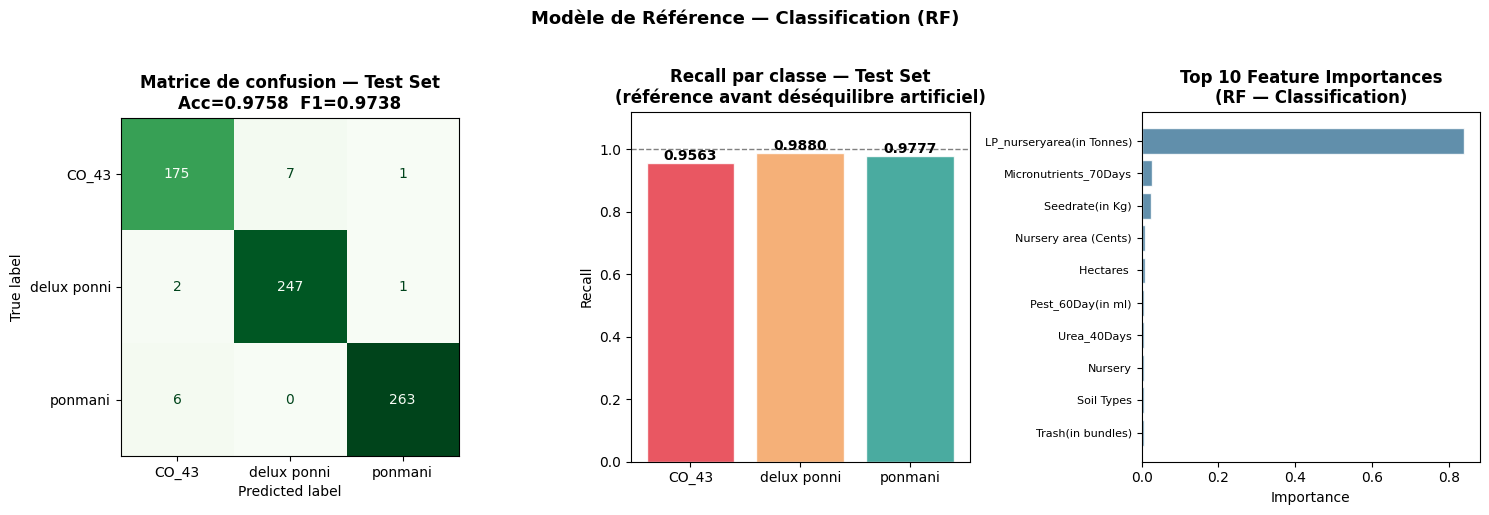

→ Feature dominante : Trash(in bundles) = 0.8395
  Cette feature représente à elle seule ~85% de l'importance du RF.
  C'est un signal fort qui sera retenu comme contexte dans le failure mode
  Failure_class_imbalance.ipynb.


In [22]:
# ── Visualisation classification ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Matrice de confusion
cm = confusion_matrix(y_te_clf, pred_te_clf, labels=CLASSES)
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(
    ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title(f'Matrice de confusion — Test Set\nAcc={acc_te:.4f}  F1={f1_te:.4f}',
                  fontweight='bold')

# 2. Recall par classe
colors_cls = [C_FAIL, C_MID, C_REF]
bars = axes[1].bar(CLASSES, [rec_te[c] for c in CLASSES],
                   color=colors_cls, edgecolor='white', alpha=0.85)
axes[1].axhline(1.0, color='gray', linestyle='--', linewidth=1)
axes[1].set_ylim(0, 1.12); axes[1].set_ylabel('Recall')
axes[1].set_title('Recall par classe — Test Set\n(référence avant déséquilibre artificiel)',
                  fontweight='bold')
for bar, val in zip(bars, [rec_te[c] for c in CLASSES]):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

# 3. Feature importances RF (top 10)
imp_clf = rf.feature_importances_
top10_rf = np.argsort(imp_clf)[-10:]
axes[2].barh(range(10), imp_clf[top10_rf],
             color=C_ACCENT, edgecolor='white', alpha=0.85)
axes[2].set_yticks(range(10))
axes[2].set_yticklabels([feat_names[i][:30] for i in top10_rf][::-1], fontsize=8)
axes[2].set_xlabel('Importance')
axes[2].set_title('Top 10 Feature Importances\n(RF — Classification)', fontweight='bold')

plt.suptitle('Modèle de Référence — Classification (RF)',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'→ Feature dominante : Trash(in bundles) = {imp_clf[np.argmax(imp_clf)]:.4f}')
print('  Cette feature représente à elle seule ~85% de l\'importance du RF.')
print('  C\'est un signal fort qui sera retenu comme contexte dans le failure mode')
print('  Failure_class_imbalance.ipynb.')


---
## Section 5 — Tableau de Synthèse des Performances de Référence

Ce tableau récapitulatif est **la référence officielle** du projet.
Toutes les comparaisons dans les notebooks de failure modes sont faites
par rapport à ces chiffres.


In [23]:
# ── Tableau de synthèse ──────────────────────────────────────────────────────
print('╔' + '═'*72 + '╗')
print(f'║  {"PERFORMANCES DE RÉFÉRENCE — PADDY DATASET":^70s}  ║')
print('╠' + '═'*72 + '╣')
print(f'║  {"Paramètre":35s}  {"Valeur":>30s}  ║')
print('╠' + '═'*72 + '╣')

rows_reg = [
    ('── RÉGRESSION (GBR) ──', ''),
    ('  Modèle', 'GradientBoostingRegressor'),
    ('  Hyperparamètres', 'n_est=200  lr=0.05  depth=4'),
    ('  Split', f'70% train ({X_tr.shape[0]}) / 30% test ({X_te.shape[0]})'),
    ('  RMSE (train)', f'{rmse_tr:.1f} Kg'),
    ('  RMSE (test)',  f'{rmse_te:.1f} Kg'),
    ('  MAE  (test)',  f'{mae_te:.1f} Kg'),
    ('  R²   (train)', f'{r2_tr:.4f}'),
    ('  R²   (test)',  f'{r2_te:.4f}'),
    ('  Gap R² train/test', f'{r2_tr - r2_te:.4f}  (pas d\'overfitting majeur)'),
]

rows_clf = [
    ('── CLASSIFICATION (RF) ──', ''),
    ('  Modèle', 'RandomForestClassifier'),
    ('  Hyperparamètres', 'n_est=200'),
    ('  Split', f'70% train ({X_tr.shape[0]}) / 30% test ({X_te.shape[0]})'),
    ('  Accuracy (test)',       f'{acc_te:.4f}'),
    ('  F1-macro (test)',       f'{f1_te:.4f}'),
    ('  Balanced Acc (test)',   f'{bal_te:.4f}'),
    ('  Recall CO_43',         f'{rec_te["CO_43"]:.4f}'),
    ('  Recall delux ponni',   f'{rec_te["delux ponni"]:.4f}'),
    ('  Recall ponmani',       f'{rec_te["ponmani"]:.4f}'),
    ('  Gap Acc train/test',   f'{acc_tr - acc_te:.4f}'),
]

for name, val in rows_reg + [('', '')] + rows_clf:
    if name == '':
        print('╠' + '─'*72 + '╣')
    elif val == '':
        print(f'║  {name:<70s}  ║')
    else:
        print(f'║  {name:<35s}  {val:>30s}  ║')

print('╚' + '═'*72 + '╝')
print()
print('  RANDOM_SEED = 42 (tous les modèles du projet)')


╔════════════════════════════════════════════════════════════════════════╗
║                PERFORMANCES DE RÉFÉRENCE — PADDY DATASET                 ║
╠════════════════════════════════════════════════════════════════════════╣
║  Paramètre                                                    Valeur  ║
╠════════════════════════════════════════════════════════════════════════╣
║  ── RÉGRESSION (GBR) ──                                                  ║
║    Modèle                                  GradientBoostingRegressor  ║
║    Hyperparamètres                       n_est=200  lr=0.05  depth=4  ║
║    Split                              70% train (1636) / 30% test (702)  ║
║    RMSE (train)                                             771.8 Kg  ║
║    RMSE (test)                                              873.6 Kg  ║
║    MAE  (test)                                              629.6 Kg  ║
║    R²   (train)                                               0.9929  ║
║    R²   (test)          

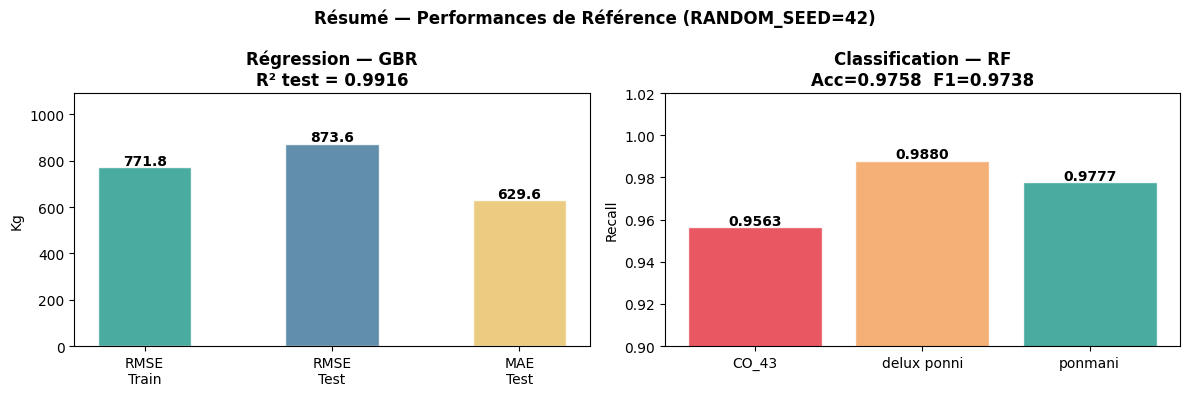


✓ Notebook de référence terminé.
  → Ouvrir Failure_distribution_shift.ipynb pour le mode d'échec principal.
  → Ouvrir Failure_class_imbalance.ipynb pour le mode d'échec bonus.


In [24]:
# ── Visualisation finale : résumé des métriques clés ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Régression — résumé barres
reg_labels = ['RMSE\nTrain', 'RMSE\nTest', 'MAE\nTest']
reg_vals   = [rmse_tr, rmse_te, mae_te]
bars = axes[0].bar(reg_labels, reg_vals, color=[C_REF, C_ACCENT, C_FIX],
                   edgecolor='white', alpha=0.85, width=0.5)
axes[0].set_ylabel('Kg')
axes[0].set_title(f'Régression — GBR\nR² test = {r2_te:.4f}', fontweight='bold')
axes[0].set_ylim(0, max(reg_vals) * 1.25)
for bar, val in zip(bars, reg_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 10,
                 f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

# Classification — recall par classe
bars2 = axes[1].bar(CLASSES, [rec_te[c] for c in CLASSES],
                    color=[C_FAIL, C_MID, C_REF], edgecolor='white', alpha=0.85)
axes[1].set_ylim(0.9, 1.02); axes[1].set_ylabel('Recall')
axes[1].set_title(f'Classification — RF\nAcc={acc_te:.4f}  F1={f1_te:.4f}',
                  fontweight='bold')
for bar, val in zip(bars2, [rec_te[c] for c in CLASSES]):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.001,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Résumé — Performances de Référence (RANDOM_SEED=42)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print()
print('✓ Notebook de référence terminé.')
print('  → Ouvrir Failure_distribution_shift.ipynb pour le mode d\'échec principal.')
print('  → Ouvrir Failure_class_imbalance.ipynb pour le mode d\'échec bonus.')
